Modèle MLP (modèle principal)
Objectif : construire, entraîner et optimiser le réseau de neurones.

In [2]:
import pickle
from joblib import numpy_pickle_compat
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import recall_score, precision_score, f1_score
import pandas as pd

# ── Chargement des données ────────────────────────────
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']
y_train        = data['y_train']
y_test         = data['y_test']

print(f"✅ Données chargées. Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

# ── Cellule 1 : Gestion du déséquilibre ───────────────
classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Poids classe 0 (légitime) : {weights[0]:.2f}")
print(f"Poids classe 1 (fraude)   : {weights[1]:.2f}")

✅ Données chargées. Train: (1296675, 35), Test: (555719, 35)
Poids classe 0 (légitime) : 0.50
Poids classe 1 (fraude)   : 86.38


In [3]:
# ── Cellule 2 : Architecture MLP ──────────────────────
n_features = X_train_scaled.shape[1]

model = Sequential([
    # Couche d'entrée + 1ère couche cachée
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # 2ème couche cachée
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # 3ème couche cachée
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Couche de sortie
    Dense(1, activation='sigmoid')
], name="MLP_FraudDetector")

model.summary()

e:\Mes_documents\3IASD\Stage\BMCE\fraud_detection_project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_FraudDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,969 (203.00 KB)

 Trainable params: 51,201 (200.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [4]:
# ── Cellule 3 : Compilation ────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [5]:
# ── Cellule 4 : Callbacks ──────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_recall',
        patience=5,
        restore_best_weights=True,
        mode='max'
    ),
    ModelCheckpoint(
        filepath='../models/mlp_best.keras',
        monitor='val_recall',
        save_best_only=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [6]:
# ── Cellule 5 : Entraînement ──────────────────────────
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - auc: 0.9360 - loss: 0.3154 - precision: 0.0365 - recall: 0.8593 - val_auc: 0.9897 - val_loss: 0.1289 - val_precision: 0.1096 - val_recall: 0.9544 - learning_rate: 0.0010
Epoch 2/50
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - auc: 0.9862 - loss: 0.1455 - precision: 0.0883 - recall: 0.9465 - val_auc: 0.9895 - val_loss: 0.1092 - val_precision: 0.1200 - val_recall: 0.9589 - learning_rate: 0.0010
Epoch 3/50
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - auc: 0.9915 - loss: 0.1156 - precision: 0.1107 - recall: 0.9602 - val_auc: 0.9901 - val_loss: 0.1097 - val_precision: 0.1290 - val_recall: 0.9614 - learning_rate: 0.0010
Epoch 4/50
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - auc: 0.9934 - loss: 0.0994 - precision: 0.1210 - recall: 0.9651 - val_auc: 0.9916 - val_loss: 0.1256 - val_precision: 0.1141 - val_recall: 0.9717 - learning_rate: 0.0010
Epoch 5/50
2027/2027 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - auc: 0.9950 - loss: 0.0869 - p

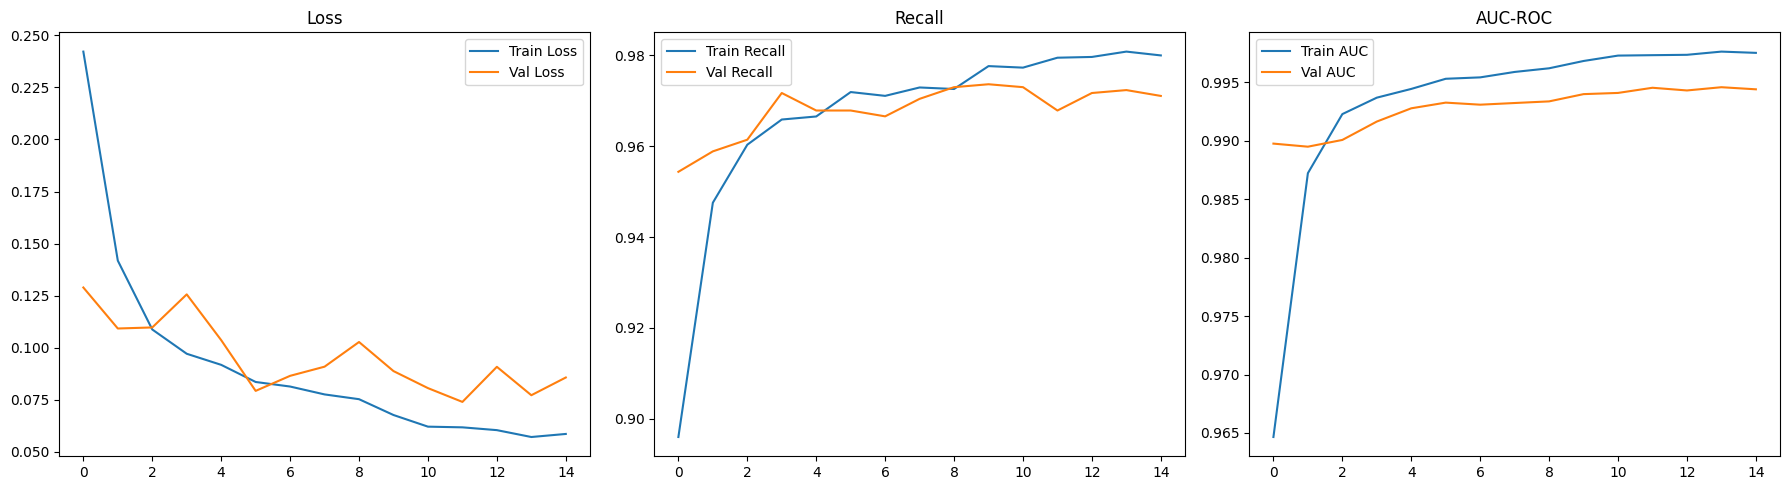

In [7]:
# ── Cellule 6 : Courbes d'apprentissage ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['recall'], label='Train Recall')
axes[1].plot(history.history['val_recall'], label='Val Recall')
axes[1].set_title('Recall')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC-ROC')
axes[2].legend()

plt.tight_layout()
plt.show()

17367/17367 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step


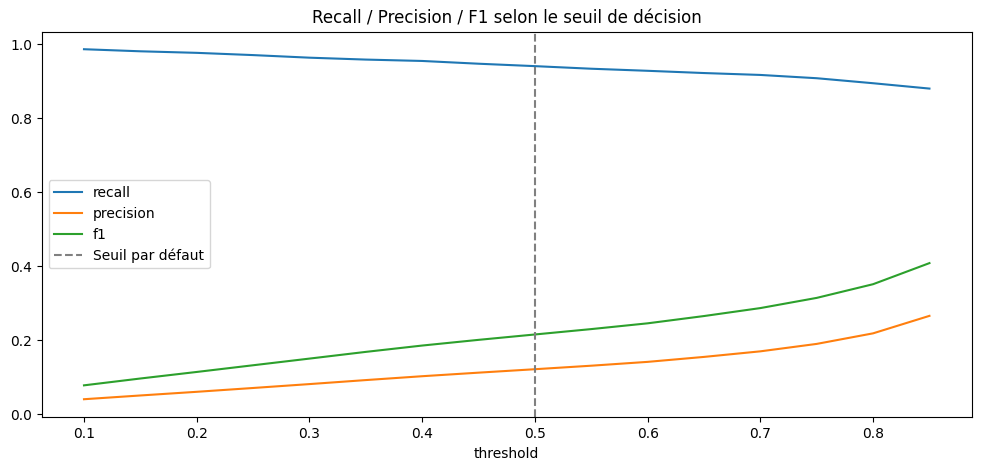

✅ Seuil optimal : 0.85
✅ Seuil sauvegardé dans '../models/mlp_threshold.pkl'


In [8]:
# ── Cellule 7 : Optimisation du seuil de décision ────
y_proba = model.predict(X_test_scaled).flatten()

thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'recall':    recall_score(y_test, y_pred_t),
        'precision': precision_score(y_test, y_pred_t),
        'f1':        f1_score(y_test, y_pred_t)
    })

results_df = pd.DataFrame(results)
results_df.plot(x='threshold', y=['recall','precision','f1'], figsize=(12,5))
plt.title("Recall / Precision / F1 selon le seuil de décision")
plt.axvline(x=0.5, color='gray', linestyle='--', label='Seuil par défaut')
plt.legend()
plt.show()

# Choisir le seuil optimal (max F1)
best_threshold = results_df.loc[results_df['f1'].idxmax(), 'threshold']
print(f"✅ Seuil optimal : {best_threshold:.2f}")

# Sauvegarder le seuil pour l'évaluation finale
with open('../models/mlp_threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)
print("✅ Seuil sauvegardé dans '../models/mlp_threshold.pkl'")

In [9]:
import json

# 1. Le modèle MLP
model.save('../models/mlp_final.keras')

# 2. Le seuil optimal choisi et la configuration
config = {
    'best_threshold': float(best_threshold),
    'model_version': '1.0',
    'n_features': int(n_features)
}

with open('../models/config.json', 'w') as f:
    json.dump(config, f)

print("✅ Modèle et configuration sauvegardés pour la plateforme web")


✅ Modèle et configuration sauvegardés pour la plateforme web
